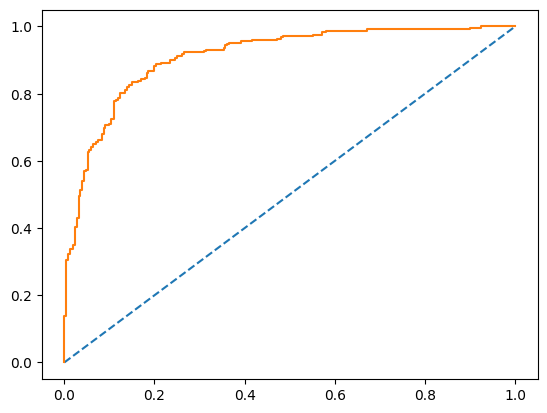

0.9105862775217615


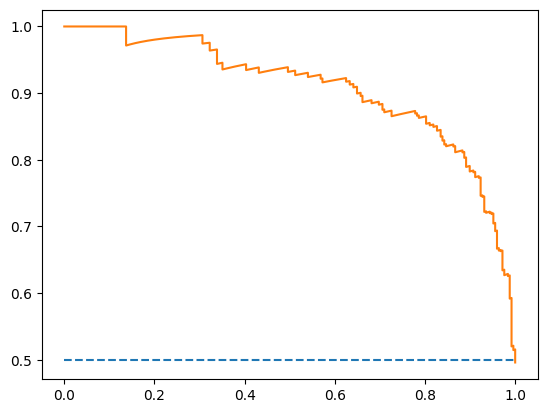

0.9074852998654053
              precision    recall  f1-score   support

           0       0.85      0.82      0.83       252
           1       0.82      0.85      0.84       248

    accuracy                           0.83       500
   macro avg       0.83      0.83      0.83       500
weighted avg       0.83      0.83      0.83       500



In [2]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification, make_blobs
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc, classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)
y_pred = model.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])

plt.plot([0, 1], [0, 1], '--')
plt.plot(fpr, tpr)
plt.show()

roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(roc_auc)

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], '--')
plt.plot(recall, precision)
plt.show()
print(auc(recall, precision))

print(classification_report(y_test, y_pred))

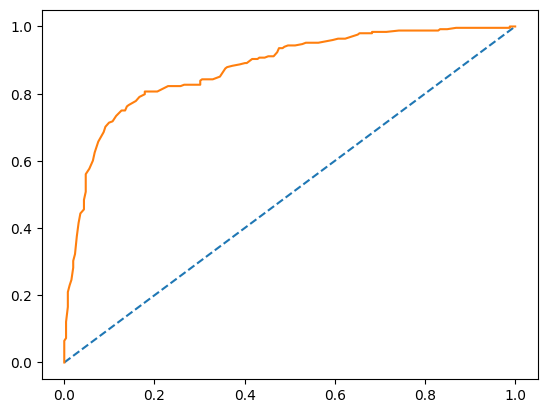

0.8756480414746544


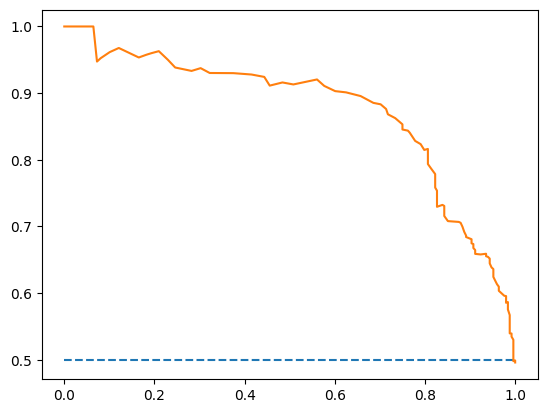

0.8750205801162659
              precision    recall  f1-score   support

           0       0.81      0.72      0.76       252
           1       0.74      0.83      0.78       248

    accuracy                           0.77       500
   macro avg       0.78      0.77      0.77       500
weighted avg       0.78      0.77      0.77       500



In [3]:
model2 = KNeighborsClassifier(n_neighbors=250)
model2.fit(X_train, y_train)
y_pred_proba = model2.predict_proba(X_test)
y_pred = model2.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])

plt.plot([0, 1], [0, 1], '--')
plt.plot(fpr, tpr)
plt.show()

roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(roc_auc)

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], '--')
plt.plot(recall, precision)
plt.show()
print(auc(recall, precision))

print(classification_report(y_test, y_pred))

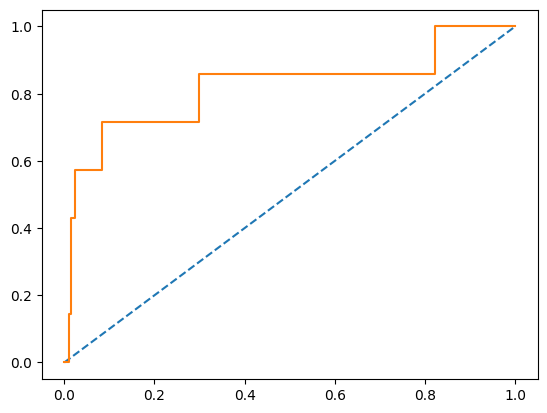

0.8191828455520139


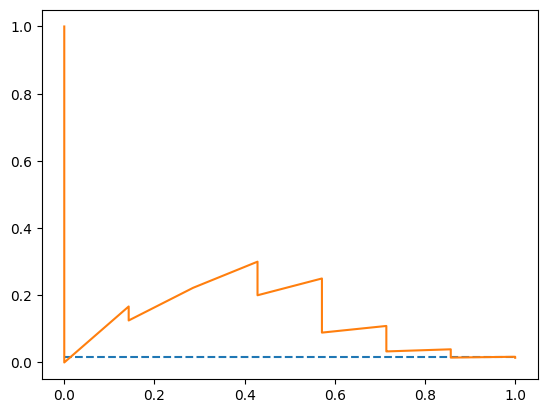

0.12767106476418924
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       493
           1       0.00      0.00      0.00         7

    accuracy                           0.98       500
   macro avg       0.49      0.50      0.50       500
weighted avg       0.97      0.98      0.98       500



In [4]:
X, y = make_classification(n_samples=1000, n_classes=2,weights=[0.99, 0.01], random_state=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)
y_pred = model.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])

plt.plot([0, 1], [0, 1], '--')
plt.plot(fpr, tpr)
plt.show()

roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(roc_auc)

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], '--')
plt.plot(recall, precision)
plt.show()
print(auc(recall, precision))

print(classification_report(y_test, y_pred))

0.37240433401587003
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4920
           1       0.79      0.14      0.23        80

    accuracy                           0.99      5000
   macro avg       0.89      0.57      0.61      5000
weighted avg       0.98      0.99      0.98      5000

0.20560207241115824
0.47540983606557374


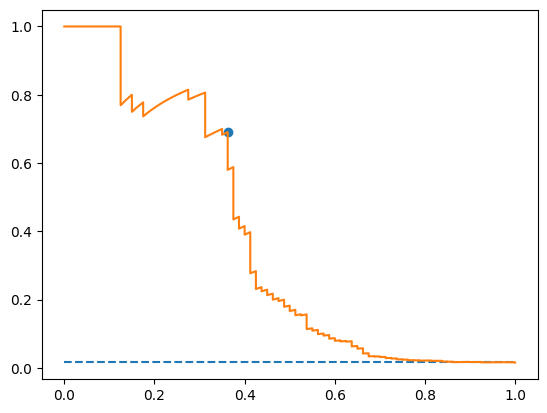

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4920
           1       0.68      0.35      0.46        80

    accuracy                           0.99      5000
   macro avg       0.84      0.67      0.73      5000
weighted avg       0.98      0.99      0.98      5000



In [5]:
from numpy import argmax
import numpy as np

X, y = make_classification(n_samples=10000, n_classes=2,weights=[0.99, 0.01], random_state=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)
y_pred = model.predict(X_test)

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], '--')
plt.plot(recall, precision)

print(auc(recall, precision))

print(classification_report(y_test, y_pred))

f1 = (2 * precision * recall) / (precision + recall)
ix = argmax(f1)
print(pr_thresholds[ix])
print(f1[ix])
plt.scatter(recall[ix], precision[ix])
plt.show()

y_pred = (y_pred_proba[:, 1] > pr_thresholds[ix]).astype('int')
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.90      0.91       250
           1       0.90      0.92      0.91       250

    accuracy                           0.91       500
   macro avg       0.91      0.91      0.91       500
weighted avg       0.91      0.91      0.91       500



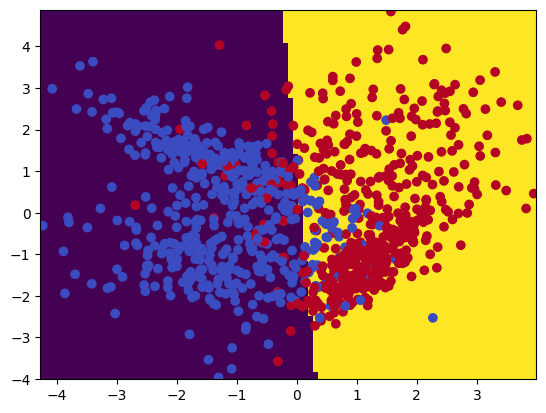

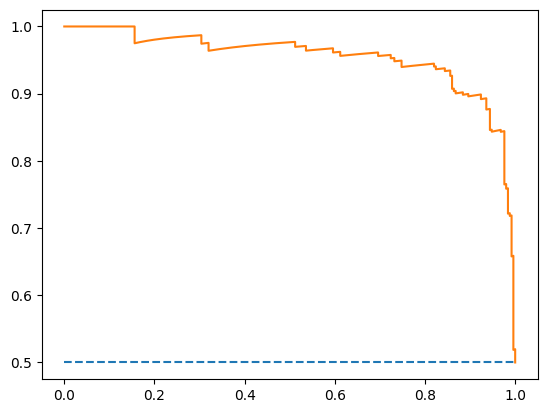

0.42698213006686103
0.9140625000000001
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       250
           1       0.89      0.93      0.91       250

    accuracy                           0.91       500
   macro avg       0.91      0.91      0.91       500
weighted avg       0.91      0.91      0.91       500



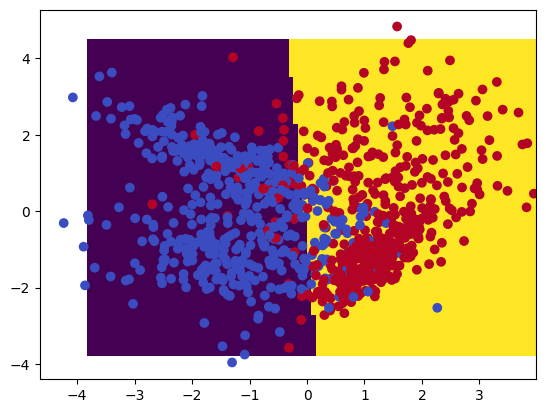

In [6]:
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,   # ← увеличили
    n_redundant=0,
    n_classes=2,
    class_sep=1.2,
    random_state=1
)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

xx0 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
xx1 = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
xx0_grid, xx1_grid  = np.meshgrid(xx0, xx1)
xx = np.c_[xx0_grid.ravel(), xx1_grid.ravel()]
yy = model.predict(xx)
yy1 = yy.reshape(xx0_grid.shape)

plt.pcolormesh(xx0_grid,xx1_grid, yy1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
plt.show()

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], '--')
plt.plot(recall, precision)
plt.show()

f1 = (2 * precision * recall) / (precision + recall)
ix = argmax(f1)
print(pr_thresholds[ix])
print(f1[ix])

y_pred = (y_pred_proba[:, 1] > pr_thresholds[ix]).astype('int')
print(classification_report(y_test, y_pred))

xx0 = np.linspace(X_test[:, 0].min(), X_test[:, 0].max(), 100)
xx1 = np.linspace(X_test[:, 1].min(), X_test[:, 1].max(), 100)
xx0_grid, xx1_grid  = np.meshgrid(xx0, xx1)
xx = np.c_[xx0_grid.ravel(), xx1_grid.ravel()]
y_pred_proba_plot = model.predict_proba(xx)
yy = (y_pred_proba_plot[:, 1] > pr_thresholds[ix]).astype('int')
yy1 = yy.reshape(xx0_grid.shape)


plt.pcolormesh(xx0_grid,xx1_grid, yy1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
plt.show()

              precision    recall  f1-score   support

           0       0.83      0.82      0.82       275
           1       0.71      0.73      0.72       171

    accuracy                           0.78       446
   macro avg       0.77      0.77      0.77       446
weighted avg       0.78      0.78      0.78       446



C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


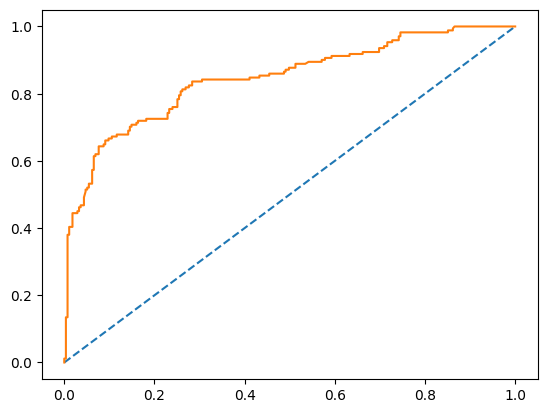

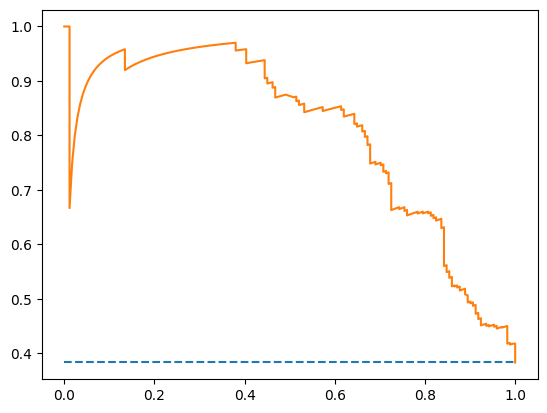

0.6126156117961107
0.7313915857605178
              precision    recall  f1-score   support

           0       0.81      0.91      0.86       275
           1       0.82      0.65      0.73       171

    accuracy                           0.81       446
   macro avg       0.81      0.78      0.79       446
weighted avg       0.81      0.81      0.81       446

0.018810947326185556
1.0
              precision    recall  f1-score   support

           0       1.00      0.00      0.01       275
           1       0.38      1.00      0.56       171

    accuracy                           0.39       446
   macro avg       0.69      0.50      0.28       446
weighted avg       0.76      0.39      0.22       446



In [7]:
data = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/refs/heads/2024/ML3.6%20bayes/titanic.csv', index_col=0)

X = data.drop('Survived', axis=1)
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

fpr, tpr, roc_thresholds= roc_curve(y_test, y_pred_proba[:, 1])

plt.plot([0, 1], [0, 1], '--')
plt.plot(fpr, tpr)
plt.show()

roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], '--')
plt.plot(recall, precision)
plt.show()

f1 = (2 * precision * recall) / (precision + recall)
ix = argmax(f1)
print(pr_thresholds[ix])
print(f1[ix])

y_pred = (y_pred_proba[:, 1] > pr_thresholds[ix]).astype('int')
print(classification_report(y_test, y_pred))

met = np.sqrt(tpr * fpr)
ix = argmax(met)
print(roc_thresholds[ix])
print(met[ix])

y_pred = (y_pred_proba[:, 1] > roc_thresholds[ix]).astype('int')
print(classification_report(y_test, y_pred))

0.6497454085149761
0.7918552036199096
              precision    recall  f1-score   support

           0       0.79      0.93      0.86       275
           1       0.85      0.61      0.71       171

    accuracy                           0.81       446
   macro avg       0.82      0.77      0.78       446
weighted avg       0.82      0.81      0.80       446

0.09546969287781454
0.794701986754967
              precision    recall  f1-score   support

           0       0.95      0.25      0.40       275
           1       0.45      0.98      0.62       171

    accuracy                           0.53       446
   macro avg       0.70      0.62      0.51       446
weighted avg       0.76      0.53      0.48       446



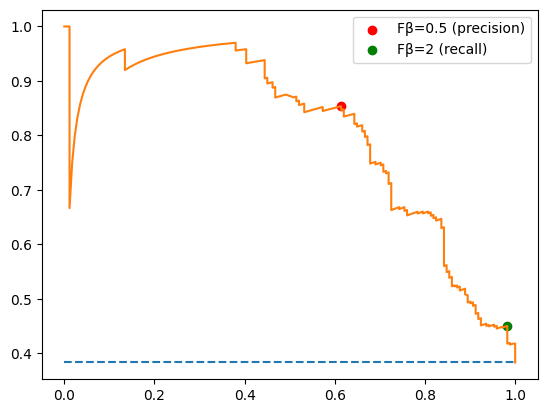

In [10]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], '--')
plt.plot(recall, precision)

beta_p = 0.5

f_beta_p = (1 + beta_p**2) * precision[:-1] * recall[:-1] / (
    beta_p**2 * precision[:-1] + recall[:-1]
)

ix_p = argmax(f_beta_p)
print(pr_thresholds[ix_p])
print(f_beta_p[ix_p])

y_pred = (y_pred_proba[:, 1] > pr_thresholds[ix_p]).astype('int')
print(classification_report(y_test, y_pred))

beta_r = 2.0
f_beta_p = (1 + beta_r**2) * precision[:-1] * recall[:-1] / (
    beta_r**2 * precision[:-1] + recall[:-1]
)

ix_r = argmax(f_beta_p)
print(pr_thresholds[ix_r])
print(f_beta_p[ix_r])

y_pred = (y_pred_proba[:, 1] > pr_thresholds[ix_r]).astype('int')
print(classification_report(y_test, y_pred))

plt.scatter(
    recall[ix_p], precision[ix_p],
    color="red", label="Fβ=0.5 (precision)"
)

plt.scatter(
    recall[ix_r], precision[ix_r],
    color="green", label="Fβ=2 (recall)"
)
plt.legend()
plt.show()

C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


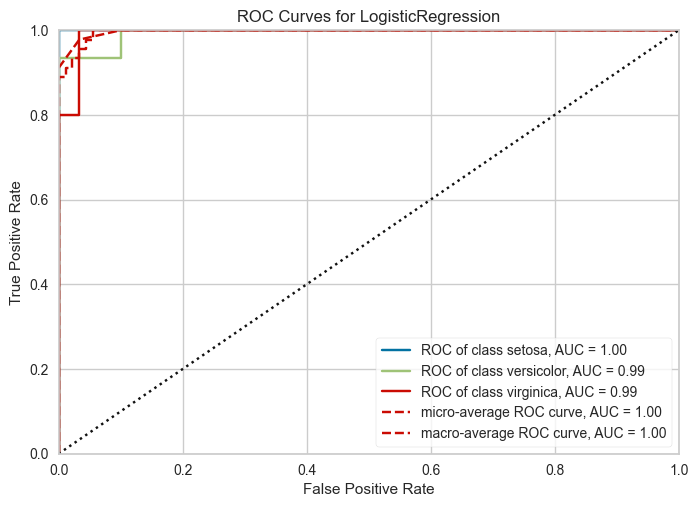

C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\yellowbrick\classifier\prcurve.py:254: YellowbrickWarning: micro=True is ignored;specify per_class=False to draw a PR curve after micro-averaging
  warnings.warn(


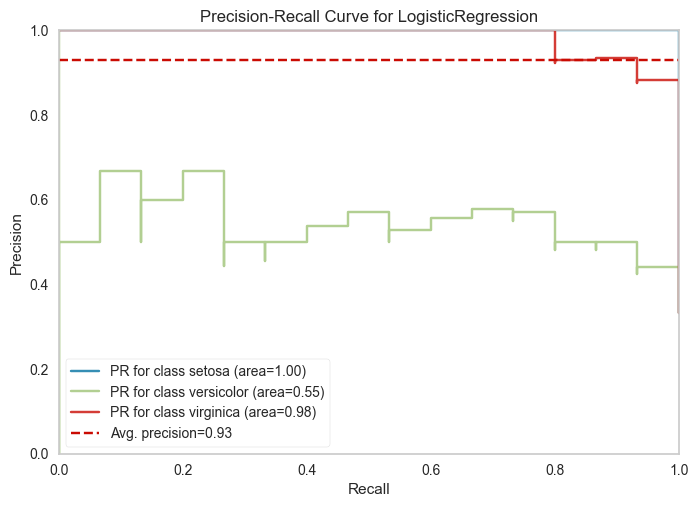

<Axes: title={'center': 'Precision-Recall Curve for LogisticRegression'}, xlabel='Recall', ylabel='Precision'>

In [23]:
from sklearn.datasets import load_iris
from yellowbrick.classifier  import ROCAUC, PrecisionRecallCurve

iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)

X = data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)


visualizer_roc = ROCAUC(model, classes=iris.target_names, micro=True, macro=True , force_model=True)
visualizer_roc.fit(X_train, y_train)
visualizer_roc.score(X_test, y_test)

visualizer_roc.show()

visualizer_pr = PrecisionRecallCurve(model, classes=iris.target_names, per_class=True, force_model=True)
visualizer_pr.fit(X_train, y_train)
visualizer_pr.score(X_test, y_test)

visualizer_pr.show()